In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving meta_open.csv to meta_open.csv
Saving temp_open_utc.csv to temp_open_utc.csv


In [ ]:
# Ajuste os nomes se necessário
df_load = pd.read_csv("temp_open_utc.csv")
df_meta = pd.read_csv("meta_open.csv")

print("Load shape:", df_load.shape)
print("Meta shape:", df_meta.shape)

Load shape: (40940, 508)
Meta shape: (507, 19)


In [ ]:
#converter timestamp
df_load['timestamp'] = pd.to_datetime(df_load['timestamp'], utc=True)
df_load = df_load.sort_values('timestamp')

In [ ]:
#calcular quantidade de dados válidos por edifício
valid_counts = df_load.drop(columns=['timestamp']).count().sort_values(ascending=False)
valid_counts.head(10)

,0
Office_Dawn,8760
Office_Benthe,8760
UnivLab_Brad,8760
UnivLab_Dianna,8760
Office_Bianca,8760
Office_Gisselle,8760
Office_Bobbi,8760
UnivClass_Tammy,8760
UnivClass_Stephanie,8760
UnivLab_Tracy,8759


In [ ]:
#verificando continuidade do candidato principal
best_building = valid_counts.index[0]
print("Edifício candidato:", best_building)

series = df_load[['timestamp', best_building]].dropna()

print("Número de registros válidos:", len(series))
print("Início:", series['timestamp'].min())
print("Fim:", series['timestamp'].max())

Edifício candidato: Office_Dawn
Número de registros válidos: 8760
Início: 2010-01-01 08:00:00+00:00
Fim: 2011-01-01 07:00:00+00:00


In [ ]:
diffs = series['timestamp'].diff().value_counts()
diffs.head()

,count
timestamp,
0 days 01:00:00,8759


tá contínuo, yay

In [ ]:
print(best_building)

Office_Dawn


ok, identificamos o edifício para realizar a replicação, agora vou só confirmar qual csv de weather é o correspondente.

In [ ]:
df_meta.columns

Index(['uid', 'dataend', 'datastart', 'energystarscore', 'heatingtype',
       'industry', 'mainheatingtype', 'numberoffloors', 'occupants',
       'primaryspaceusage', 'rating', 'sqft', 'sqm', 'subindustry', 'timezone',
       'yearbuilt', 'nickname', 'primaryspaceuse_abbrev',
       'newweatherfilename'],
      dtype='object')

In [ ]:
df_meta[df_meta['uid'] == best_building][
    ['uid', 'timezone', 'newweatherfilename']
]

,uid,timezone,newweatherfilename
460,Office_Dawn,America/Los_Angeles,weather13.csv


In [ ]:
uploaded = files.upload()


Saving weather13.csv to weather13.csv


In [ ]:
df_weather = pd.read_csv("weather13.csv")

df_weather.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,timestamp,Conditions,DateUTC<br />,Dew PointC,Events,Gust SpeedKm/h,Humidity,Precipitationmm,Sea Level PressurehPa,TemperatureC,TimeCDT,TimeCST,VisibilityKm,Wind Direction,Wind SpeedKm/h,WindDirDegrees,timestamp.1
0,2010-01-01 00:10:00,Clear,2010-01-01 06:10:00<br />,-18.8,NaN,-,88.0,NaN,1029.0,-17.2,NaN,12:10 AM,11.3,Calm,Calm,0,2010-01-01 00:10:00
1,2010-01-01 00:30:00,Clear,2010-01-01 06:30:00<br />,-18.5,NaN,-,88.0,NaN,1029.0,-17.0,NaN,12:30 AM,11.3,Calm,Calm,0,2010-01-01 00:30:00
2,2010-01-01 00:50:00,Clear,2010-01-01 06:50:00<br />,-18.3,NaN,-,88.0,NaN,1029.0,-16.7,NaN,12:50 AM,11.3,Calm,Calm,0,2010-01-01 00:50:00
3,2010-01-01 01:10:00,Clear,2010-01-01 07:10:00<br />,-19.6,NaN,-,86.0,NaN,1029.0,-17.8,NaN,1:10 AM,11.3,Calm,Calm,0,2010-01-01 01:10:00
4,2010-01-01 01:30:00,Clear,2010-01-01 07:30:00<br />,-19.4,NaN,-,88.0,NaN,1028.7,-17.8,NaN,1:30 AM,11.3,Calm,Calm,0,2010-01-01 01:30:00


In [ ]:
df_weather.columns

Index(['timestamp', 'Conditions', 'DateUTC<br />', 'Dew PointC', 'Events',
       'Gust SpeedKm/h', 'Humidity', 'Precipitationmm',
       'Sea Level PressurehPa', 'TemperatureC', 'TimeCDT', 'TimeCST',
       'VisibilityKm', 'Wind Direction', 'Wind SpeedKm/h', 'WindDirDegrees',
       'timestamp.1'],
      dtype='object')

In [ ]:
df_weather['timestamp'] = pd.to_datetime(
    df_weather['timestamp'],
    format="%Y-%m-%d %H:%M:%S"
) #converter timestamp

In [ ]:
df_weather = df_weather[['timestamp', 'TemperatureC']] #selecionar apenas o necessário

In [ ]:
df_weather = df_weather.set_index('timestamp') #transformar em série horária

df_weather_hourly = df_weather.resample('1h').mean()

In [ ]:
df_weather_hourly.shape #conferir tamanho

(8760, 1)

In [ ]:
df_weather_hourly.head()

,TemperatureC
timestamp,
2010-01-01 00:00:00,-16.966667
2010-01-01 01:00:00,-17.900000
2010-01-01 02:00:00,-17.366667
2010-01-01 03:00:00,-17.133333
2010-01-01 04:00:00,-16.333333


O timestamp não tem informações de fuso mas sabemos pelo meta_open que o prédio está los angeles.
O procedimento cientificamente correto agora é:

Declarar que o weather está em Los Angeles Time

Converter para UTC

Alinhar com o consumo

Isso garantirá que o clima e o consumo estejam alinhados.

In [ ]:
df_weather_hourly.index = df_weather_hourly.index.tz_localize(
    "America/Los_Angeles",
    ambiguous="NaT",
    nonexistent="shift_forward"
)

In [ ]:
df_weather_hourly = df_weather_hourly.dropna()

In [ ]:
df_weather_hourly = df_weather_hourly.tz_convert("UTC")

Agora o weather está em UTC 🙂

In [ ]:
df_building = df_load[['timestamp', best_building]].copy()

df_building['timestamp'] = pd.to_datetime(df_building['timestamp'])

df_building = df_building.set_index('timestamp')

df_building.head()

,Office_Dawn
timestamp,
2010-01-01 08:00:00+00:00,313.75
2010-01-01 09:00:00+00:00,357.25
2010-01-01 10:00:00+00:00,348.00
2010-01-01 11:00:00+00:00,340.75
2010-01-01 12:00:00+00:00,319.50


In [ ]:
df_building.index

DatetimeIndex(['2010-01-01 08:00:00+00:00', '2010-01-01 09:00:00+00:00',
               '2010-01-01 10:00:00+00:00', '2010-01-01 11:00:00+00:00',
               '2010-01-01 12:00:00+00:00', '2010-01-01 13:00:00+00:00',
               '2010-01-01 14:00:00+00:00', '2010-01-01 15:00:00+00:00',
               '2010-01-01 16:00:00+00:00', '2010-01-01 17:00:00+00:00',
               ...
               '2015-12-31 21:00:00+00:00', '2015-12-31 22:00:00+00:00',
               '2015-12-31 23:00:00+00:00', '2016-01-01 00:00:00+00:00',
               '2016-01-01 01:00:00+00:00', '2016-01-01 02:00:00+00:00',
               '2016-01-01 03:00:00+00:00', '2016-01-01 04:00:00+00:00',
               '2016-01-01 05:00:00+00:00', '2016-01-01 06:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='timestamp', length=40940, freq=None)

In [ ]:
df_merged = df_building.join(df_weather_hourly)

df_merged.head()

,Office_Dawn,TemperatureC
timestamp,,
2010-01-01 08:00:00+00:00,313.75,-16.966667
2010-01-01 09:00:00+00:00,357.25,-17.900000
2010-01-01 10:00:00+00:00,348.00,-17.366667
2010-01-01 11:00:00+00:00,340.75,-17.133333
2010-01-01 12:00:00+00:00,319.50,-16.333333


In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 40940 entries, 2010-01-01 08:00:00+00:00 to 2016-01-01 06:00:00+00:00
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Office_Dawn   8760 non-null   float64
 1   TemperatureC  8732 non-null   float64
dtypes: float64(2)
memory usage: 959.5 KB


In [ ]:
df_merged = df_merged.dropna() #removendo linhas sem consumo ou sem temperatura

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8732 entries, 2010-01-01 08:00:00+00:00 to 2011-01-01 07:00:00+00:00
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Office_Dawn   8732 non-null   float64
 1   TemperatureC  8732 non-null   float64
dtypes: float64(2)
memory usage: 204.7 KB


In [ ]:
df_merged["hour"] = df_merged.index.hour

Vamos extrair por hora do dia.
Agora vamos criar as variáveis seno e cosseno, no artigo a ser replicado eles usam número e amostras por dia, porém como estamos usando dados horários faremos L=24

In [ ]:
L=24

df_merged["sin_time"] = np.sin(2*np.pi*df_merged["hour"]/L)
df_merged["cos_time"] = np.cos(2*np.pi*df_merged["hour"]/L)

In [ ]:
df_merged.head()

,Office_Dawn,TemperatureC,hour,sin_time,cos_time
timestamp,,,,,
2010-01-01 08:00:00+00:00,313.75,-16.966667,8,8.660254e-01,-0.500000
2010-01-01 09:00:00+00:00,357.25,-17.900000,9,7.071068e-01,-0.707107
2010-01-01 10:00:00+00:00,348.00,-17.366667,10,5.000000e-01,-0.866025
2010-01-01 11:00:00+00:00,340.75,-17.133333,11,2.588190e-01,-0.965926
2010-01-01 12:00:00+00:00,319.50,-16.333333,12,1.224647e-16,-1.000000


Com isso replicamos a seguinte parte do artigo "Temporal indicators of sample data information in a day in the form of sine and cosine"

Agora vamos pra parte de pseudo-dynamic features, como o artigo cita que o consumo atual depende do que aconteceu antes nos vamos ao invés de usar um modelo sequência (LSTM) vamos seguir o que o artigo fez e pegar valores passados (lags) e colocar como colunas no modelo, imitando a dinâmica (por isso pseudo-dinâmica)

In [ ]:
#começando simples e fiel ao artigo, vamos dar início criando lags básicas
df_merged["lag_1"] = df_merged["Office_Dawn"].shift(1)
df_merged["lag_2"] = df_merged["Office_Dawn"].shift(2)
df_merged["lag_3"] = df_merged["Office_Dawn"].shift(3)

In [ ]:
#criar um lag diário que é extremamente importante pro quesito da energia para capturar o que aconteceu no dia anteriro no mesmo horário
df_merged["lag_24"] = df_merged["Office_Dawn"].shift(24)


In [ ]:
#criar um lag semanal (é opcional? é mas as vezes pode ser útil)
df_merged["lag_168"] = df_merged["Office_Dawn"].shift(168)
#é 168 porque 168 = 24 * 7 para pegar mesmo horário na semana passada

In [ ]:
#remover NaNs gerados pelos lags
df_merged = df_merged.dropna()


In [ ]:
df_merged.head()

,Office_Dawn,TemperatureC,hour,sin_time,cos_time,lag_1,lag_2,lag_3,lag_24,lag_168
timestamp,,,,,,,,,,
2010-01-08 10:00:00+00:00,355.25,-20.000000,10,5.000000e-01,-0.866025,371.25,328.25,288.25,300.25,313.75
2010-01-08 11:00:00+00:00,347.25,-20.166667,11,2.588190e-01,-0.965926,355.25,371.25,328.25,325.25,357.25
2010-01-08 12:00:00+00:00,330.75,-20.200000,12,1.224647e-16,-1.000000,347.25,355.25,371.25,302.50,348.00
2010-01-08 13:00:00+00:00,317.25,-20.233333,13,-2.588190e-01,-0.965926,330.75,347.25,355.25,292.00,340.75
2010-01-08 14:00:00+00:00,196.00,-20.566667,14,-5.000000e-01,-0.866025,317.25,330.75,347.25,187.25,319.50


Aqui nós implementamos as partes do artigo descritas como:

"transition information of energy load characteristics"

"thermal inertia of buildings"

ou seja, o modelo aprende que o comportamento energético de um prédio não muda instantaneamente, ele carrega memória do passado, já que a inércia térmica significa que o prédio demora a mudar de temperatura e o consumo passado influencia no consumo futuro.

Agora só falta uma peça do artigo, DTW (dynamic time warping), que os autores usaram para selecionar dias semelhantes antes de treinar o SVM.

Mas antes vamos treinar um SVM de baseline para garantirmos que temos uma base sólida e que está tudo funcionando mesmo.

In [ ]:
#para montar o SVM baseline vamos começar definindo X e y.
X = df_merged.drop(columns=["Office_Dawn"])
y = df_merged["Office_Dawn"]

In [ ]:
#agora dividiremos em treino e teste temporal. Lembrar de não usar shuffle
split = int(0.8 * len(df_merged))

X_train = X.iloc[:split]
X_teste = X.iloc[split:]

y_train = y.iloc[:split]
y_teste = y.iloc[split:]

In [ ]:
#normalizar os dados porque o SVM precisa de escala
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_teste_scaled = scaler.transform(X_teste)

In [ ]:
#treinar o SVM
from sklearn.svm import SVR

model = SVR(kernel='rbf')

model.fit(X_train_scaled, y_train)

SVR()

In [ ]:
#prever (ou tentar)
y_pred = model.predict(X_teste_scaled)

In [ ]:
#avaliar no que deu
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse=np.sqrt(mean_squared_error(y_teste, y_pred))
mae=mean_absolute_error(y_teste, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)



RMSE: 22.489867550287904
MAE: 15.012877189112713


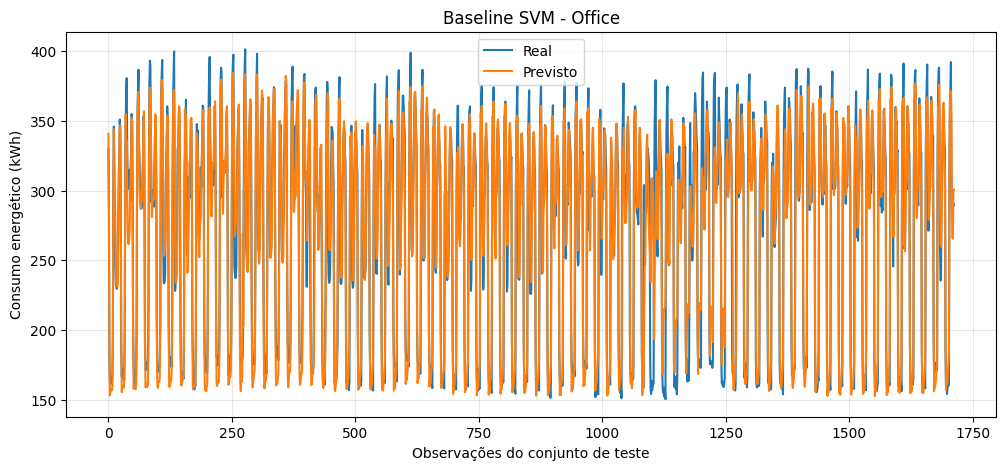

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_teste.values, label="Real")
plt.plot(y_pred, label="Previsto")

plt.title("Baseline SVM - Office")
plt.xlabel("Observações do conjunto de teste")
plt.ylabel("Consumo energético (kWh)")   # ou apenas "Consumo energético" se não tiver unidade

plt.legend()
plt.grid(alpha=0.3)

plt.show()

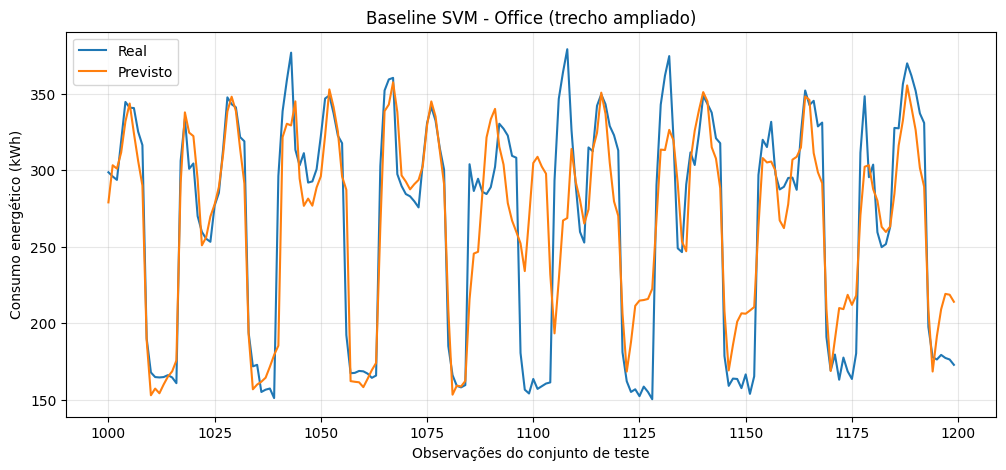

In [ ]:
inicio = 1000
fim = 1200

plt.figure(figsize=(12,5))

plt.plot(
    range(inicio, fim),
    y_teste.values[inicio:fim],
    label="Real"
)

plt.plot(
    range(inicio, fim),
    y_pred[inicio:fim],
    label="Previsto"
)

plt.title("Baseline SVM - Office (trecho ampliado)")
plt.xlabel("Observações do conjunto de teste")
plt.ylabel("Consumo energético (kWh)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Analizando isso aqui.

Mae é aproximadamente 15, que é um erro médio baixo considerando valores na faixa ente 150 e 400.

Rmse ta aproximadamente 22, o que inclui alguns erros maiores mas nada fora do esperado.

é um baseline bem sólido até, agora sobre o gráfico, o modelo acompanha bem o padrão geral, captura claramente o comportamento periódico que são os ciclos diários, e apresenta pequenas diferenças nos picos o que é normal num SVM. Acredito que o mais importante é que o modelo aprendeu a estrutura do consumo energético.

outra forma (e mais bonita) de dizer isso para por no TCC depois (sim eu gastei tempo pensando nisso):

Os resultados demonstram que o modelo SVM, mesmo em sua configuração baseline, foi capaz de capturar adequadamente os padrões temporais do consumo energético do edifício, incluindo sua periodicidade diária. A inclusão de variáveis climáticas e pseudo-dinâmicas mostrou-se suficiente para modelar a inércia do sistema, ainda que com pequenas discrepâncias em picos de consumo.



Uma das coisas que podemos melhorar do baseline é que ele usa todos os dados e isso pode confundir o modelo, é ai que vai entrar o DTW, vamos usar ele para ao invés de pegar todos os dados, pegar apenas os do dia alvo.

Assim a ideia é comparar os dias pela temepratura, selecionar os mais parecidos e treinar o SVM só nesses dias, dessa forma completaremos a replica exata do Artigo base.

In [ ]:
#transformar os dados em dias

df_merged["date"] = df_merged.index.date #criação da coluna de data
df_merged["hour"] = df_merged.index.hour #coluna de hora

In [ ]:
daily_temp = df_merged.pivot_table(
    values="TemperatureC",
    index="date",
    columns="hour"
) #pivotar a temperatura por dia

In [ ]:
daily_temp.head()

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2010-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-20.566667,-20.800000,-20.700000,-19.733333,-18.833333,-17.733333,-16.700000,-15.9,-15.266667,-14.800000
2010-01-09,-14.966667,-16.000000,-17.200000,-18.5,-19.566667,-20.566667,-21.433333,-22.133333,-23.000000,-23.066667,...,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.0,-3342.633333,-13.800000
2010-01-10,-13.666667,-14.933333,-16.433333,-17.1,-17.133333,-16.550000,-15.766667,-16.100000,-15.933333,-15.533333,...,-12.933333,-12.400000,-11.133333,-9.633333,-8.466667,-6.833333,-5.233333,-3.4,-2.133333,-1.100000
2010-01-11,-1.133333,-1.766667,-1.866667,-1.9,-1.733333,-2.133333,-3.133333,-3.366667,-3.666667,-2.900000,...,-2.733333,-3.633333,-3.766667,-2.366667,-1.800000,-2.133333,-1.600000,-0.5,-0.233333,-0.566667
2010-01-12,-1.566667,-2.000000,-2.500000,-3.1,-3.666667,-3.933333,-4.100000,-4.400000,-4.566667,-3336.333333,...,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-6658.333333,-9999.0,-9999.000000,-6666.233333


In [ ]:
#tá funcionando, agora é remover os dias incompletos já que queremos 24 horas certinhas
daily_temp = daily_temp.dropna()

In [ ]:
daily_temp.shape

(345, 24)

In [ ]:
#aquele -9999 de temperatura não tá legal... concertar
df_merged["TemperatureC"] = df_merged["TemperatureC"].replace(-9999, np.nan)

In [ ]:
#refazer o pivot
daily_temp = df_merged.pivot_table(
    values="TemperatureC",
    index="date",
    columns="hour"
)

In [ ]:
daily_temp = daily_temp.dropna()

In [ ]:
daily_temp.head()


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2010-01-10,-13.666667,-14.933333,-16.433333,-17.100000,-17.133333,-16.550000,-15.766667,-16.100000,-15.933333,-15.533333,...,-12.933333,-12.400000,-11.133333,-9.633333,-8.466667,-6.833333,-5.233333,-3.4,-2.133333,-1.100000
2010-01-11,-1.133333,-1.766667,-1.866667,-1.900000,-1.733333,-2.133333,-3.133333,-3.366667,-3.666667,-2.900000,...,-2.733333,-3.633333,-3.766667,-2.366667,-1.800000,-2.133333,-1.600000,-0.5,-0.233333,-0.566667
2010-01-16,2.233333,-0.033333,-1.300000,-2.233333,-3.500000,-4.566667,-4.533333,-4.166667,-3.366667,-2.800000,...,-5.200000,-5.266667,-4.100000,-3.966667,-1.100000,1.100000,2.500000,3.5,3.800000,3.200000
2010-01-17,3.233333,1.733333,0.266667,-0.466667,1.000000,0.766667,0.133333,-0.466667,-1.166667,-2.733333,...,-5.400000,-5.266667,-4.666667,-2.200000,-0.033333,1.666667,2.733333,3.6,4.000000,3.633333
2010-01-18,2.766667,7.650000,-0.200000,-0.500000,-0.733333,-0.900000,-0.633333,-0.633333,-0.966667,-0.933333,...,-1.600000,-1.600000,-1.500000,-1.233333,-1.100000,-1.200000,-1.033333,-0.9,-0.666667,-0.500000


In [ ]:
daily_temp.shape

(339, 24)

339 dias funcionais com 24 horas completas e sem valores inválidos agora podemos escolher um dia alvo, comparar com os outros e encontrar os dias mais parecidos com eles.

In [ ]:
#instalar a biblioteca de DTW agora
!pip install dtaidistance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 60.9 MB/s eta 0:00:00


In [ ]:
from dtaidistance import dtw

In [ ]:
#escolher dia alvo
target_day = daily_temp.index[100]

print("Dia alvo:", target_day)

Dia alvo: 2010-04-25


In [ ]:
#pegando a curva do dia alvo
target_series = daily_temp.loc[target_day].values

In [ ]:
#calcular a distância do DTW para todos os dias
distances = {}

for day in daily_temp.index:

    if day == target_day:
        continue

    current_series = daily_temp.loc[day].values

    distance = dtw.distance(target_series, current_series)

    distances[day] = distance

In [ ]:
#ordenar os dias mais parecidos
sorted_days = sorted(distances.items(), key=lambda x: x[1])

In [ ]:
#mostrar os mais similares
for day, dist in sorted_days[:10]:
    print(day, "->", dist)

2010-04-22 -> 3.08859910711061
2010-05-16 -> 6.2024188829842855
2010-04-16 -> 6.370548554786229
2010-10-24 -> 6.759437846448475
2010-05-19 -> 7.223918604192606
2010-04-21 -> 7.4007694795128485
2010-09-19 -> 8.28279676330539
2010-05-20 -> 8.35967503355643
2010-10-02 -> 8.544950588245408
2010-04-24 -> 8.756870318657105


In [ ]:
#selecionar os dias similares, acho que usar 12 dias deve estar bom
top_days = [day for day, dist in sorted_days[:12]]

top_days

[datetime.date(2010, 4, 22),
 datetime.date(2010, 5, 16),
 datetime.date(2010, 4, 16),
 datetime.date(2010, 10, 24),
 datetime.date(2010, 5, 19),
 datetime.date(2010, 4, 21),
 datetime.date(2010, 9, 19),
 datetime.date(2010, 5, 20),
 datetime.date(2010, 10, 2),
 datetime.date(2010, 4, 24),
 datetime.date(2010, 10, 18),
 datetime.date(2010, 5, 9)]

In [ ]:
#criar dataset reduzido
df_dtw = df_merged[df_merged["date"].isin(top_days)].copy()

In [ ]:
df_dtw.shape


(288, 11)

In [ ]:
df_dtw.head()

,Office_Dawn,TemperatureC,hour,sin_time,cos_time,lag_1,lag_2,lag_3,lag_24,lag_168,date
timestamp,,,,,,,,,,,
2010-04-16 00:00:00+00:00,258.50,18.633333,0,0.000000,1.000000,346.00,373.00,404.00,293.50,265.75,2010-04-16
2010-04-16 01:00:00+00:00,254.75,18.166667,1,0.258819,0.965926,258.50,346.00,373.00,244.50,248.00,2010-04-16
2010-04-16 02:00:00+00:00,248.00,17.533333,2,0.500000,0.866025,254.75,258.50,346.00,242.25,253.25,2010-04-16
2010-04-16 03:00:00+00:00,245.75,17.066667,3,0.707107,0.707107,248.00,254.75,258.50,255.50,252.25,2010-04-16
2010-04-16 04:00:00+00:00,240.75,16.133333,4,0.866025,0.500000,245.75,248.00,254.75,256.25,256.50,2010-04-16


In [ ]:
#agora ao invés de treinar o SVM com todos os dias do ano vamos treinar apenas com os dias climaticamente semeplhantes, seguindo o artigo
X_dtw = df_dtw.drop(columns=["Office_Dawn", "date"])
y_dtw = df_dtw["Office_Dawn"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_dtw = StandardScaler()

X_dtw_scaled = scaler_dtw.fit_transform(X_dtw)

In [ ]:
from sklearn.svm import SVR

model_dtw = SVR(kernel="rbf")

model_dtw.fit(X_dtw_scaled, y_dtw)

SVR()

In [ ]:
#extrair dados do dia alvo
df_target = df_merged[df_merged["date"] == target_day].copy()

In [ ]:
X_target = df_target.drop(columns=["Office_Dawn", "date"])
y_target = df_target["Office_Dawn"]

In [ ]:
X_target_scaled = scaler_dtw.transform(X_target)

In [ ]:
y_pred_dtw = model_dtw.predict(X_target_scaled)

In [ ]:
#avaliar pra ver no que dá
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_dtw = np.sqrt(mean_squared_error(y_target, y_pred_dtw))
mae_dtw = mean_absolute_error(y_target, y_pred_dtw)

print("DTW RMSE:", rmse_dtw)
print("DTW MAE:", mae_dtw)

DTW RMSE: 86.47358930928777
DTW MAE: 64.26946336702389


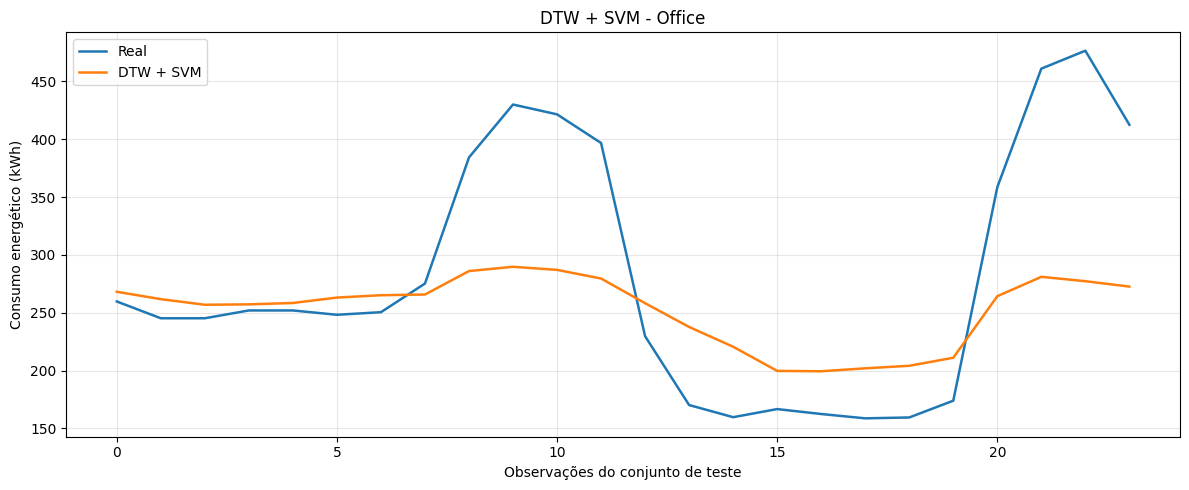

In [ ]:


plt.figure(figsize=(12,5))

plt.plot(y_target.values, label="Real", linewidth=1.8)
plt.plot(y_pred_dtw, label="DTW + SVM", linewidth=1.8)

plt.title("DTW + SVM - Office")
plt.xlabel("Observações do conjunto de teste")
plt.ylabel("Consumo energético (kWh)")   # ou apenas "Consumo energético"

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

ok ficou MUITO pior, o DTW ficou "suavizado demais", ele não conseguiu aprender picos bruscos em reproduzir as mudanças abruptas de consumo.
Isso sugere que pro Office_Dawn o comportamento energético NÃO depende só da similaridade climática, provavelmente depende mais de coisas como rotina operacional, ocupação, horário de funcionamento, comportamento humano e eventos internos.

O que querendo ou não é muito coerente para um escritório, que pode até ter temperatura muito parecidas mas consumos muito diferentes devido a fatores como reuniões, quantidade de pessoas, uso de equipamentos, iluminação e HVAC programado que mudam muito.

E o principal, O baseline já tinha: lags, memória temporal e pseudo-dinâmica.
Então ele já capturava que o prédio tende a repetir o próprio comportamento.

Enquanto o DTW tentou usar outros dias parecidos.

Mas os dias parecidos climaticamente não eram energeticamente tão parecidos.

Ainda sim essa piora não inválida a metodologia já que usamos uma versão mais simplificada do DTW e não a mais técnica.

##Hipotese encontrada: Para edifícios de escritório, a similaridade climática isolada pode não ser suficiente para melhorar a previsão energética.

tentar mais alguns testes para dias

In [ ]:
#escolher 1 dia válido por mês
monthly_targets = []

# transformar índice em datetime
daily_temp.index = pd.to_datetime(daily_temp.index)

# percorrer meses
for month in range(1, 13):

    month_days = daily_temp[
        daily_temp.index.month == month
    ].index

    # garantir que existe pelo menos 1 dia
    if len(month_days) > 0:

        # escolher um dia aleatório
        chosen_day = np.random.choice(month_days)

        monthly_targets.append(chosen_day)

print(monthly_targets)

[np.datetime64('2010-01-11T00:00:00.000000000'), np.datetime64('2010-02-18T00:00:00.000000000'), np.datetime64('2010-03-01T00:00:00.000000000'), np.datetime64('2010-04-24T00:00:00.000000000'), np.datetime64('2010-05-16T00:00:00.000000000'), np.datetime64('2010-06-04T00:00:00.000000000'), np.datetime64('2010-07-25T00:00:00.000000000'), np.datetime64('2010-08-30T00:00:00.000000000'), np.datetime64('2010-09-19T00:00:00.000000000'), np.datetime64('2010-10-14T00:00:00.000000000'), np.datetime64('2010-11-22T00:00:00.000000000'), np.datetime64('2010-12-27T00:00:00.000000000')]


In [ ]:
#lista para guardar os resultados
rmse_list = []
mae_list = []

In [ ]:
#pra o loop não quebrar por diferença de formato
df_merged["date"] = pd.to_datetime(df_merged["date"])

In [ ]:
#loop do DTW
for target_day in monthly_targets:

    print(f"\nProcessando: {target_day}")

    #série alvo
    target_series = daily_temp.loc[target_day].values

    #calcular distâncias
    distances = {}

    for day in daily_temp.index:

        if day == target_day:
            continue

        current_series = daily_temp.loc[day].values

        distance = dtw.distance(
            target_series,
            current_series
        )

        distances[day] = distance

    #ordenar
    sorted_days = sorted(
        distances.items(),
        key=lambda x: x[1]
    )

    #top dias similares
    top_days = [
        day for day, dist in sorted_days[:12]
    ]

    #dataset DTW
    df_dtw = df_merged[
        df_merged["date"].isin(top_days)
    ].copy()

    #target day
    df_target = df_merged[
        df_merged["date"] == target_day
    ].copy()

    #features e target treino
    X_train = df_dtw.drop(
        columns=["Office_Dawn", "date"]
    )

    y_train = df_dtw["Office_Dawn"]

    #features target
    X_test = df_target.drop(
        columns=["Office_Dawn", "date"]
    )

    y_test = df_target["Office_Dawn"]

    #scaler
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    #modelo
    model = SVR(kernel="rbf")

    model.fit(X_train_scaled, y_train)

    #previsão
    y_pred = model.predict(X_test_scaled)

    #métricas
    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    mae = mean_absolute_error(y_test, y_pred)

    print("RMSE:", rmse)
    print("MAE:", mae)

    rmse_list.append(rmse)
    mae_list.append(mae)


Processando: 2010-01-11T00:00:00.000000000
RMSE: 69.57061939380242
MAE: 57.15334441747391

Processando: 2010-02-18T00:00:00.000000000
RMSE: 80.0384145216873
MAE: 69.61695783896593

Processando: 2010-03-01T00:00:00.000000000
RMSE: 80.33079816745325
MAE: 75.01162183237696

Processando: 2010-04-24T00:00:00.000000000
RMSE: 67.64275527951118
MAE: 56.411550448625576

Processando: 2010-05-16T00:00:00.000000000
RMSE: 54.95302505717119
MAE: 47.43028259447035

Processando: 2010-06-04T00:00:00.000000000
RMSE: 42.409553578212176
MAE: 32.543557972284006

Processando: 2010-07-25T00:00:00.000000000
RMSE: 26.095849724405497
MAE: 20.708849350625403

Processando: 2010-08-30T00:00:00.000000000
RMSE: 41.47713298557659
MAE: 31.740809719683167

Processando: 2010-09-19T00:00:00.000000000
RMSE: 34.96078220619067
MAE: 32.18970383964424

Processando: 2010-10-14T00:00:00.000000000
RMSE: 42.7359385982825
MAE: 36.2203627671166

Processando: 2010-11-22T00:00:00.000000000
RMSE: 72.73315653843719
MAE: 58.06362959522

In [ ]:
print("RMSE médio:", np.mean(rmse_list))
print("MAE médio:", np.mean(mae_list))

print("Desvio RMSE:", np.std(rmse_list))
print("Desvio MAE:", np.std(mae_list))

RMSE médio: 56.48156370586033
MAE médio: 47.27283545276848
Desvio RMSE: 17.687798218205856
Desvio MAE: 16.04233099288532


agora com vários períodos no ano ao invés de apenas um dia aleatório o experimento fica melhor embasado, e por mais que o RMSE médio de 58 e o MAE de 48 sejam melhores que o dia isolado com RMSE 86 e o MAE 64, eles ainda são piores que o baseline onde o RMSE 22 e MAE 15, com isso agora podemos afirmar que A estratégia baseada em similaridade climática apresentou desempenho inferior ao treinamento global no edifício analisado, e mesmo considerando múltiplos períodos do ano, o método DTW não superou o baseline.

Isso sugere que o método DTW é instável funcionando melhor em alguns meses e em outros não.

Possíveis causas:
*   Ocupação variável
*   Reuniões
*   Equipamentos
*   Feriados
*   Uso irregular

Logo dias climaticamente parecidos não são dias energeticamente parecidos
Uma interpretação sociotécnica disso seria que o consumo energético não é determinado apenas por fatores ambientais, mas também por dinâmicas sociais e operacionais do edifício.

Testar em um prédio de dormitórios para ver o contraste

In [ ]:
#e lá vamos nóóós para os prédios de dormitório

dorm_cols = [
    col for col in df_load.columns
    if "UnivDorm" in col
]

missing_dorm = {}

for col in dorm_cols:

    missing_percent = (
        df_load[col].isna().mean() * 100
    )

    missing_dorm[col] = missing_percent

missing_dorm = pd.Series(missing_dorm)

missing_dorm.sort_values().head(10)

,0
UnivDorm_Malachi,78.607719
UnivDorm_Mathew,78.607719
UnivDorm_Marquis,78.607719
UnivDorm_Malcolm,78.607719
UnivDorm_Marlene,78.610161
UnivDorm_Laura,78.610161
UnivDorm_Mckenzie,78.637030
UnivDorm_Mauricio,78.666341
UnivDorm_Lorraine,78.671226
UnivDorm_Leslie,78.690767


In [ ]:
best_dorm = missing_dorm.sort_values().index[0]

print(best_dorm)

UnivDorm_Malachi


In [ ]:
df_meta[
    df_meta["uid"] == best_dorm
][[
    "uid",
    "timezone",
    "newweatherfilename"
]]


,uid,timezone,newweatherfilename
211,UnivDorm_Malachi,America/Chicago,weather3.csv


In [ ]:
uploaded = files.upload()

Saving weather3.csv to weather3.csv


In [ ]:
df_weather_dorms = pd.read_csv("weather3.csv")

df_weather_dorms.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,timestamp,Conditions,DateUTC<br />,Dew PointC,Events,Gust SpeedKm/h,Humidity,Precipitationmm,Sea Level PressurehPa,TemperatureC,TimeCDT,TimeCST,VisibilityKm,Wind Direction,Wind SpeedKm/h,WindDirDegrees,timestamp.1
0,2014-05-01 00:53:00,Light Drizzle,2014-05-01 05:53:00<br />,3.9,NaN,-,100.0,0.0,1007.3,3.9,12:53 AM,NaN,6.4,NNW,18.5,330,2014-05-01 00:53:00
1,2014-05-01 01:01:00,Overcast,2014-05-01 06:01:00<br />,3.9,NaN,-,100.0,0.0,1006.7,3.9,1:01 AM,NaN,8.0,NNW,18.5,330,2014-05-01 01:01:00
2,2014-05-01 01:10:00,Overcast,2014-05-01 06:10:00<br />,3.9,NaN,-,100.0,0.0,1006.7,3.9,1:10 AM,NaN,12.9,NW,18.5,320,2014-05-01 01:10:00
3,2014-05-01 01:19:00,Overcast,2014-05-01 06:19:00<br />,3.9,NaN,-,100.0,0.0,1006.7,3.9,1:19 AM,NaN,14.5,NNW,20.4,340,2014-05-01 01:19:00
4,2014-05-01 01:29:00,Overcast,2014-05-01 06:29:00<br />,3.3,NaN,-,93.0,0.0,1006.3,4.4,1:29 AM,NaN,16.1,NNW,16.7,330,2014-05-01 01:29:00


In [ ]:
df_weather_dorms.columns

Index(['timestamp', 'Conditions', 'DateUTC<br />', 'Dew PointC', 'Events',
       'Gust SpeedKm/h', 'Humidity', 'Precipitationmm',
       'Sea Level PressurehPa', 'TemperatureC', 'TimeCDT', 'TimeCST',
       'VisibilityKm', 'Wind Direction', 'Wind SpeedKm/h', 'WindDirDegrees',
       'timestamp.1'],
      dtype='object')

In [ ]:
df_weather_dorms["timestamp"] = pd.to_datetime(
    df_weather_dorms["timestamp"],
    errors="coerce"
)

In [ ]:
df_weather_dorms = df_weather_dorms[
    ["timestamp", "TemperatureC"]
]

In [ ]:
df_weather_dorms = df_weather_dorms.set_index(
    "timestamp"
)

In [ ]:
df_weather_hourly_dorm = (
    df_weather_dorms
    .resample("1h")
    .mean()
)

In [ ]:
df_weather_hourly_dorm.index = (
    df_weather_hourly_dorm.index
    .tz_localize(
        "America/Chicago",
        ambiguous=True,
        nonexistent="shift_forward"
    )
)

In [ ]:
df_weather_hourly_dorm = (
    df_weather_hourly_dorm
    .tz_convert("UTC")
)

In [ ]:
df_dorm = df_load[['timestamp', best_dorm]].copy()

df_dorm['timestamp'] = pd.to_datetime(df_dorm['timestamp'])

df_dorm = df_dorm.set_index('timestamp')

df_dorm.head()

,UnivDorm_Malachi
timestamp,
2010-01-01 08:00:00+00:00,NaN
2010-01-01 09:00:00+00:00,NaN
2010-01-01 10:00:00+00:00,NaN
2010-01-01 11:00:00+00:00,NaN
2010-01-01 12:00:00+00:00,NaN


In [ ]:
df_dorm.index

DatetimeIndex(['2010-01-01 08:00:00+00:00', '2010-01-01 09:00:00+00:00',
               '2010-01-01 10:00:00+00:00', '2010-01-01 11:00:00+00:00',
               '2010-01-01 12:00:00+00:00', '2010-01-01 13:00:00+00:00',
               '2010-01-01 14:00:00+00:00', '2010-01-01 15:00:00+00:00',
               '2010-01-01 16:00:00+00:00', '2010-01-01 17:00:00+00:00',
               ...
               '2015-12-31 21:00:00+00:00', '2015-12-31 22:00:00+00:00',
               '2015-12-31 23:00:00+00:00', '2016-01-01 00:00:00+00:00',
               '2016-01-01 01:00:00+00:00', '2016-01-01 02:00:00+00:00',
               '2016-01-01 03:00:00+00:00', '2016-01-01 04:00:00+00:00',
               '2016-01-01 05:00:00+00:00', '2016-01-01 06:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='timestamp', length=40940, freq=None)

In [ ]:
df_merged_dorm = df_dorm.join(df_weather_hourly_dorm)

df_merged_dorm.head()

,UnivDorm_Malachi,TemperatureC
timestamp,,
2010-01-01 08:00:00+00:00,NaN,NaN
2010-01-01 09:00:00+00:00,NaN,NaN
2010-01-01 10:00:00+00:00,NaN,NaN
2010-01-01 11:00:00+00:00,NaN,NaN
2010-01-01 12:00:00+00:00,NaN,NaN


In [ ]:
df_merged_dorm.head()

,UnivDorm_Malachi,TemperatureC
timestamp,,
2010-01-01 08:00:00+00:00,NaN,NaN
2010-01-01 09:00:00+00:00,NaN,NaN
2010-01-01 10:00:00+00:00,NaN,NaN
2010-01-01 11:00:00+00:00,NaN,NaN
2010-01-01 12:00:00+00:00,NaN,NaN


In [ ]:
#diagnosticar uma coisa aqui
print(df_dorm.index[:5])

print(df_weather_hourly_dorm.index[:5])

DatetimeIndex(['2010-01-01 08:00:00+00:00', '2010-01-01 09:00:00+00:00',
               '2010-01-01 10:00:00+00:00', '2010-01-01 11:00:00+00:00',
               '2010-01-01 12:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='timestamp', freq=None)
DatetimeIndex(['2014-05-01 05:00:00+00:00', '2014-05-01 06:00:00+00:00',
               '2014-05-01 07:00:00+00:00', '2014-05-01 08:00:00+00:00',
               '2014-05-01 09:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='timestamp', freq=None)


In [ ]:
print(df_dorm.index.tz)

print(df_weather_hourly_dorm.index.tz)

UTC
UTC


In [ ]:
print(df_dorm.index[:10])

print(df_weather_hourly_dorm.index[:10])

DatetimeIndex(['2010-01-01 08:00:00+00:00', '2010-01-01 09:00:00+00:00',
               '2010-01-01 10:00:00+00:00', '2010-01-01 11:00:00+00:00',
               '2010-01-01 12:00:00+00:00', '2010-01-01 13:00:00+00:00',
               '2010-01-01 14:00:00+00:00', '2010-01-01 15:00:00+00:00',
               '2010-01-01 16:00:00+00:00', '2010-01-01 17:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='timestamp', freq=None)
DatetimeIndex(['2014-05-01 05:00:00+00:00', '2014-05-01 06:00:00+00:00',
               '2014-05-01 07:00:00+00:00', '2014-05-01 08:00:00+00:00',
               '2014-05-01 09:00:00+00:00', '2014-05-01 10:00:00+00:00',
               '2014-05-01 11:00:00+00:00', '2014-05-01 12:00:00+00:00',
               '2014-05-01 13:00:00+00:00', '2014-05-01 14:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='timestamp', freq=None)


In [ ]:
print(best_dorm)

UnivDorm_Malachi


In [ ]:
df_meta[
    df_meta["uid"] == best_dorm
][[
    "uid",
    "datastart",
    "dataend",
    "newweatherfilename"
]]

,uid,datastart,dataend,newweatherfilename
211,UnivDorm_Malachi,01/05/14 00:00,30/04/15 23:00,weather3.csv


In [ ]:
df_dorm = df_dorm.dropna()

In [ ]:
df_dorm.head()


,UnivDorm_Malachi
timestamp,
2014-05-01 05:00:00+00:00,103.75
2014-05-01 06:00:00+00:00,98.00
2014-05-01 07:00:00+00:00,99.75
2014-05-01 08:00:00+00:00,95.50
2014-05-01 09:00:00+00:00,88.75


In [ ]:
df_dorm.index.min()


Timestamp('2014-05-01 05:00:00+0000', tz='UTC')

In [ ]:
df_dorm.index.max()

Timestamp('2015-05-01 04:00:00+0000', tz='UTC')

In [ ]:
df_merged_dorm = df_dorm.join(
    df_weather_hourly_dorm,
    how="inner"
)

In [ ]:
df_merged_dorm.head()

,UnivDorm_Malachi,TemperatureC
timestamp,,
2014-05-01 05:00:00+00:00,103.75,3.90
2014-05-01 06:00:00+00:00,98.00,4.15
2014-05-01 07:00:00+00:00,99.75,3.90
2014-05-01 08:00:00+00:00,95.50,3.60
2014-05-01 09:00:00+00:00,88.75,3.30


In [ ]:
df_merged_dorm.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8758 entries, 2014-05-01 05:00:00+00:00 to 2015-05-01 04:00:00+00:00
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   UnivDorm_Malachi  8758 non-null   float64
 1   TemperatureC      8719 non-null   float64
dtypes: float64(2)
memory usage: 205.3 KB


Agoooora resolveu, nossa senhora porque tudo que é multimodal da tanto trabalho? bom, para a pseudo-dinamica eu vou

In [ ]:
df_merged_dorm["TemperatureC"] = (
    df_merged_dorm["TemperatureC"]
    .replace(-9999, np.nan)
)

In [ ]:
df_merged_dorm = df_merged_dorm.dropna()

In [ ]:
df_merged_dorm["hour"] = (
    df_merged_dorm.index.hour
)

df_merged_dorm["day_of_week"] = (
    df_merged_dorm.index.dayofweek
)

In [ ]:
df_merged_dorm["hour_sin"] = np.sin(
    2 * np.pi * df_merged_dorm["hour"] / 24
)

df_merged_dorm["hour_cos"] = np.cos(
    2 * np.pi * df_merged_dorm["hour"] / 24
)

In [ ]:
df_merged_dorm["lag_1h"] = (
    df_merged_dorm["UnivDorm_Malachi"]
    .shift(1)
)

df_merged_dorm["lag_24h"] = (
    df_merged_dorm["UnivDorm_Malachi"]
    .shift(24)
)

In [ ]:
df_merged_dorm = df_merged_dorm.dropna()

In [ ]:
df_merged_dorm.head()

,UnivDorm_Malachi,TemperatureC,hour,day_of_week,hour_sin,hour_cos,lag_1h,lag_24h
timestamp,,,,,,,,
2014-05-02 05:00:00+00:00,110.75,7.2,5,4,0.965926,2.588190e-01,115.25,103.75
2014-05-02 06:00:00+00:00,98.00,7.2,6,4,1.000000,6.123234e-17,110.75,98.00
2014-05-02 07:00:00+00:00,92.25,7.2,7,4,0.965926,-2.588190e-01,98.00,99.75
2014-05-02 08:00:00+00:00,86.75,6.7,8,4,0.866025,-5.000000e-01,92.25,95.50
2014-05-02 09:00:00+00:00,85.00,6.7,9,4,0.707107,-7.071068e-01,86.75,88.75


In [ ]:
df_merged_dorm.shape

(8695, 8)

o mini dataset do dormitório tá ótimo, agora é fazer o baseline dele para primeira impressão antes de tentar pegar dias específicos

In [ ]:
train_size_dorm = int(len(df_merged_dorm) * 0.8)

train_dorm = df_merged_dorm.iloc[:train_size_dorm]
test_dorm = df_merged_dorm.iloc[train_size_dorm:]

In [ ]:
X_train_dorm = train_dorm.drop(
    columns=["UnivDorm_Malachi"]
)

y_train_dorm = train_dorm["UnivDorm_Malachi"]

X_test_dorm = test_dorm.drop(
    columns=["UnivDorm_Malachi"]
)

y_test_dorm = test_dorm["UnivDorm_Malachi"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_dorm = StandardScaler()

X_train_scaled_dorm = scaler.fit_transform(X_train_dorm)

X_test_scaled_dorm = scaler.transform(X_test_dorm)

In [ ]:
from sklearn.svm import SVR

model_dorm = SVR(kernel="rbf")

model_dorm.fit(X_train_scaled_dorm, y_train_dorm)

SVR()

In [ ]:
y_pred_dorm = model_dorm.predict(X_test_scaled_dorm)

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

rmse_dorm = np.sqrt(
    mean_squared_error(y_test_dorm, y_pred_dorm)
)

mae_dorm = mean_absolute_error(
    y_test_dorm,
    y_pred_dorm
)

print("RMSE:", rmse_dorm)
print("MAE:", mae_dorm)

RMSE: 7.981379745523948
MAE: 6.098279492271838


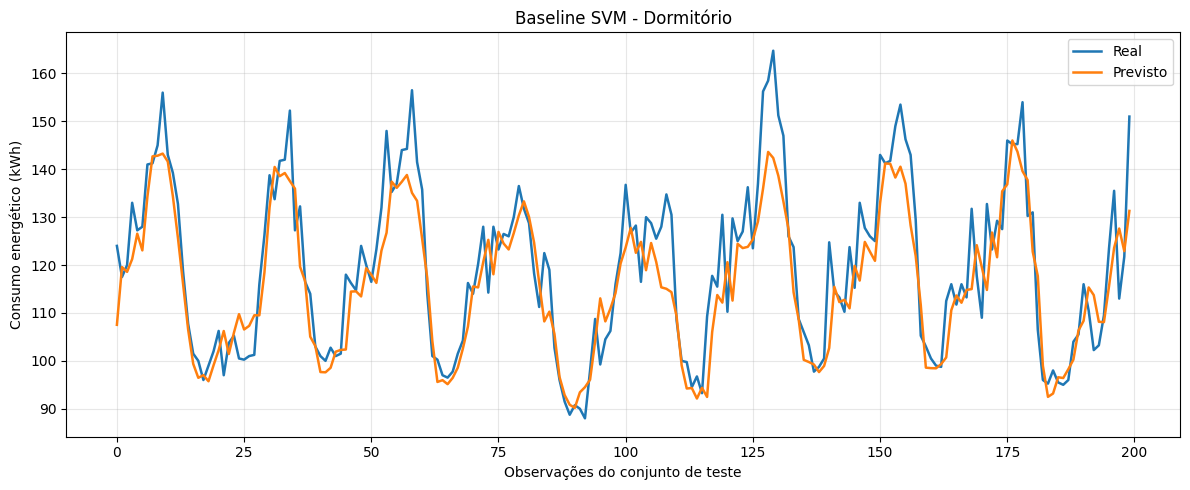

In [ ]:


plt.figure(figsize=(12,5))

plt.plot(
    y_test_dorm.values[:200],
    label="Real",
    linewidth=1.8
)

plt.plot(
    y_pred_dorm[:200],
    label="Previsto",
    linewidth=1.8
)

plt.title("Baseline SVM - Dormitório")
plt.xlabel("Observações do conjunto de teste")
plt.ylabel("Consumo energético (kWh)")   # ou "Consumo energético"

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

ok, hipótese que vou levantar aqui: dormitórios possuem comportamento energético mais previsível que escritórios. isso poderia levar a uma facilitação de começar a implementar modelos de energia sustentável em dormitórios para um impacto mais imediato enquanto ainda está sendo feito o avanço para prever os outros tipos de prédios com esse nível de precisão. Inclusive isso confirma minha hipotese de que o consumo de energia não depende apenas de estrutura ou clima mas também do modo de ocupação humana.

Vamos ver se já que é mais estável o DTW funciona melhor nesse prédio

In [ ]:
df_merged_dorm["date"] = (
    df_merged_dorm.index.date
)

In [ ]:
daily_temp_dorm = (
    df_merged_dorm
    .pivot_table(
        index="date",
        columns=df_merged_dorm.index.hour,
        values="TemperatureC"
    )
)

In [ ]:
daily_temp_dorm = (
    daily_temp_dorm
    .dropna()
)

In [ ]:
daily_temp_dorm.head()

timestamp,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2014-05-03,12.8,11.1,10.600000,9.4,8.900,8.900000,8.300000,7.20,6.1,7.00,...,11.1,11.7,12.2,13.9,15.00,14.00,13.3,13.900,13.3,12.2
2014-05-04,11.7,10.0,9.400000,8.9,8.300,7.200000,6.100000,5.60,4.4,3.30,...,6.1,7.8,10.0,11.7,11.95,13.30,12.8,13.900,13.3,12.8
2014-05-05,12.8,12.2,12.200000,12.2,11.700,11.700000,11.100000,11.10,10.6,10.60,...,12.8,13.3,14.4,16.0,16.10,16.70,16.7,17.200,17.2,16.7
2014-05-07,17.2,16.1,15.600000,13.9,13.300,13.300000,12.800000,12.20,11.7,11.70,...,12.2,14.4,16.0,16.7,17.80,17.75,16.7,16.700,16.7,17.2
2014-05-08,17.2,16.1,15.533333,13.3,12.925,12.233333,11.866667,11.05,10.6,10.85,...,14.4,16.1,17.0,19.0,20.30,19.40,18.8,14.675,14.7,14.4


In [ ]:
daily_temp_dorm.shape

(334, 24)

334 dias funcionando com 24 horas completas muito bom

In [ ]:
monthly_targets_dorm = []

daily_temp_dorm.index = pd.to_datetime(
    daily_temp_dorm.index
)

for month in range(1, 13):

    month_days = daily_temp_dorm[
        daily_temp_dorm.index.month == month
    ].index

    if len(month_days) > 0:

        chosen_day = np.random.choice(
            month_days
        )

        monthly_targets_dorm.append(
            chosen_day
        )

print(monthly_targets_dorm)

[np.datetime64('2015-01-31T00:00:00.000000000'), np.datetime64('2015-02-21T00:00:00.000000000'), np.datetime64('2015-03-28T00:00:00.000000000'), np.datetime64('2015-04-06T00:00:00.000000000'), np.datetime64('2014-05-08T00:00:00.000000000'), np.datetime64('2014-06-28T00:00:00.000000000'), np.datetime64('2014-07-29T00:00:00.000000000'), np.datetime64('2014-08-03T00:00:00.000000000'), np.datetime64('2014-09-07T00:00:00.000000000'), np.datetime64('2014-10-23T00:00:00.000000000'), np.datetime64('2014-11-10T00:00:00.000000000'), np.datetime64('2014-12-22T00:00:00.000000000')]


In [ ]:
rmse_list_dorm = []
mae_list_dorm = []

In [ ]:
df_merged_dorm["date"] = pd.to_datetime(
    df_merged_dorm["date"]
)

In [ ]:
for target_day in monthly_targets_dorm:

    print(f"\nProcessando: {target_day}")

    target_series = (
        daily_temp_dorm
        .loc[target_day]
        .values
    )

    distances = {}

    for day in daily_temp_dorm.index:

        if day == target_day:
            continue

        current_series = (
            daily_temp_dorm
            .loc[day]
            .values
        )

        distance = dtw.distance(
            target_series,
            current_series
        )

        distances[day] = distance

    sorted_days = sorted(
        distances.items(),
        key=lambda x: x[1]
    )

    top_days = [
        day for day, dist in sorted_days[:12]
    ]

    df_dtw_dorm = df_merged_dorm[
    df_merged_dorm["date"].isin(
        pd.to_datetime(top_days)
    )
].copy()

    df_target_dorm = df_merged_dorm[
    df_merged_dorm["date"] == pd.Timestamp(target_day)
].copy()

    X_train_dorm = df_dtw_dorm.drop(
        columns=[
            "UnivDorm_Malachi",
            "date"
        ]
    )

    y_train_dorm = (
        df_dtw_dorm["UnivDorm_Malachi"]
    )

    X_test_dorm = df_target_dorm.drop(
        columns=[
            "UnivDorm_Malachi",
            "date"
        ]
    )

    y_test_dorm = (
        df_target_dorm["UnivDorm_Malachi"]
    )

    scaler_dorm = StandardScaler()

    X_train_scaled_dorm = (
        scaler_dorm.fit_transform(
            X_train_dorm
        )
    )

    X_test_scaled_dorm = (
        scaler_dorm.transform(
            X_test_dorm
        )
    )

    model_dorm = SVR(kernel="rbf")

    model_dorm.fit(
        X_train_scaled_dorm,
        y_train_dorm
    )

    y_pred_dorm = model_dorm.predict(
        X_test_scaled_dorm
    )

    rmse_dorm = np.sqrt(
        mean_squared_error(
            y_test_dorm,
            y_pred_dorm
        )
    )

    mae_dorm = mean_absolute_error(
        y_test_dorm,
        y_pred_dorm
    )

    print("RMSE:", rmse_dorm)
    print("MAE:", mae_dorm)

    rmse_list_dorm.append(
        rmse_dorm
    )

    mae_list_dorm.append(
        mae_dorm
    )


Processando: 2015-01-31T00:00:00.000000000
RMSE: 14.093650042325995
MAE: 10.743303136749171

Processando: 2015-02-21T00:00:00.000000000
RMSE: 6.400842050104444
MAE: 5.050868774269159

Processando: 2015-03-28T00:00:00.000000000
RMSE: 7.955730648438569
MAE: 6.843510895208297

Processando: 2015-04-06T00:00:00.000000000
RMSE: 10.303579793731036
MAE: 8.950345480242367

Processando: 2014-05-08T00:00:00.000000000
RMSE: 9.09020739082731
MAE: 7.825722162125689

Processando: 2014-06-28T00:00:00.000000000
RMSE: 3.207167204536334
MAE: 2.8748251704175485

Processando: 2014-07-29T00:00:00.000000000
RMSE: 3.6525653897127768
MAE: 3.0052289516469615

Processando: 2014-08-03T00:00:00.000000000
RMSE: 2.4061424370650832
MAE: 1.8382679474368997

Processando: 2014-09-07T00:00:00.000000000
RMSE: 29.199377317926704
MAE: 25.950014461743162

Processando: 2014-10-23T00:00:00.000000000
RMSE: 10.405416854590827
MAE: 7.816128854362186

Processando: 2014-11-10T00:00:00.000000000
RMSE: 11.732398506923026
MAE: 10.403

In [ ]:
print("RMSE médio:", np.mean(rmse_list_dorm))

print("MAE médio:", np.mean(mae_list_dorm))

print("Desvio RMSE:", np.std(rmse_list_dorm))

print("Desvio MAE:", np.std(mae_list_dorm))

RMSE médio: 10.41227804397729
MAE médio: 8.938260422419505
Desvio RMSE: 7.017272437389374
Desvio MAE: 6.379952937283759


A eficácia do DTW depende do perfil funcional do edifício.

Em edifícios com comportamento energético mais regular, como dormitórios, o DTW tende a apresentar desempenho mais estável.

Em edifícios com operação dinâmica e ocupação variável, como escritórios, a seleção de dias similares baseada apenas em temperatura pode degradar o desempenho.

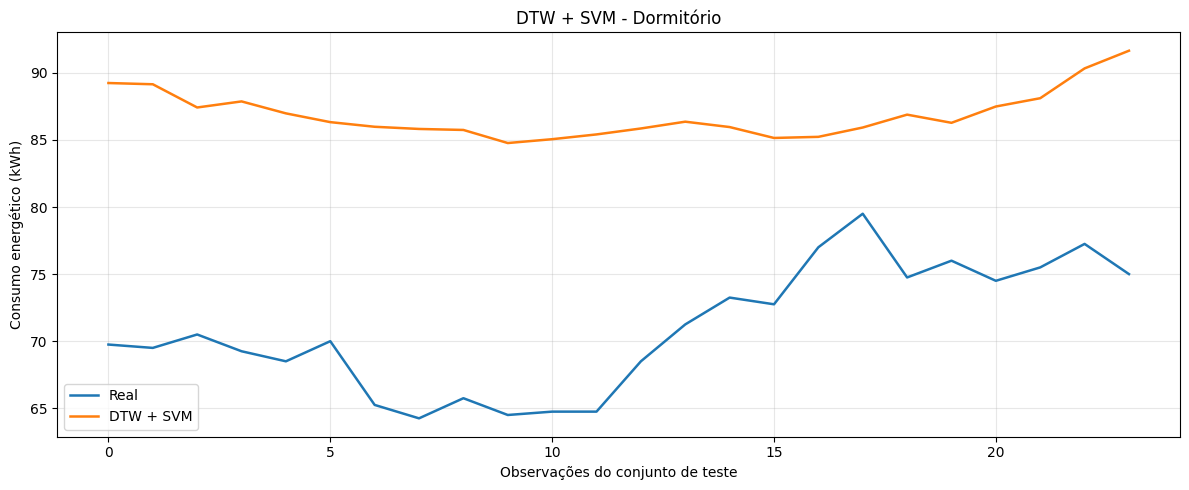

In [ ]:


plt.figure(figsize=(12,5))

plt.plot(
    y_test_dorm.values,
    label="Real",
    linewidth=1.8
)

plt.plot(
    y_pred_dorm,
    label="DTW + SVM",
    linewidth=1.8
)

plt.title("DTW + SVM - Dormitório")
plt.xlabel("Observações do conjunto de teste")
plt.ylabel("Consumo energético (kWh)")   # ou apenas "Consumo energético"

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()